# MVP Análise de Dados e Boas Práticas

**Nome:** MARCELA PHOLYANA DE OLIVEIRA DA SILVA

**Matrícula:** 4052026000575

**Dataset:**

# Descrição do Problema

Este trabalho tem como objetivo analisar um dataset relacionado à predição de doença cardíaca. O problema consiste em identificar, com base em características clínicas e demográficas dos pacientes, se há indícios de presença de doença cardíaca. A proposta do MVP é compreender os dados, explorar padrões, verificar a distribuição das variáveis e aplicar etapas de pré-processamento que preparem a base para futuras modelagens preditivas.

## Hipóteses do Problema

As hipóteses consideradas neste trabalho são:

1. Algumas variáveis clínicas, como tipo de dor no peito, frequência cardíaca máxima e depressão do segmento ST, podem ter relação com a presença de doença cardíaca.
2. O dataset apresenta atributos com escalas diferentes, tornando importante aplicar técnicas de normalização e padronização.
3. Pode haver correlação entre algumas variáveis numéricas, o que pode influenciar etapas futuras de modelagem.
4. A distribuição da classe alvo pode indicar se há ou não desbalanceamento entre pacientes com e sem doença cardíaca.

## Tipo de Problema

Este é um problema de aprendizado supervisionado do tipo classificação binária, pois existe uma variável alvo que indica a presença (1) ou ausência (0) de doença cardíaca.

## Seleção de Dados

Foi escolhido um dataset público sobre doença cardíaca disponível em repositório online. A base foi selecionada por ser adequada para um problema de classificação, possuir atributos numéricos e categóricos, e permitir a aplicação das etapas de análise exploratória e pré-processamento vistas na disciplina.

## Atributos do Dataset

Os principais atributos do dataset são:

- age: idade do paciente
- sex: sexo do paciente
- cp: tipo de dor no peito
- trestbps: pressão arterial em repouso
- chol: colesterol sérico
- fbs: glicemia em jejum
- restecg: resultado do eletrocardiograma em repouso
- thalach: frequência cardíaca máxima atingida
- exang: angina induzida por exercício
- oldpeak: depressão do segmento ST induzida por exercício
- slope: inclinação do segmento ST
- ca: número de vasos principais coloridos
- thal: resultado do exame de talassemia
- target: presença (1) ou ausência (0) de doença cardíaca

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset de doença cardíaca.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [3]:
# carregamento do dataset (aqui, ele fica disponível nesse método)
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(url)

In [4]:
# guardo o dataset em um dataframe
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# primeiras linhas
# dataset carregado com sucesso

# Análise de Dados

Nesta etapa de Análise Exploratória de Dados (EDA), buscamos compreender a estrutura do dataset de doença cardíaca, suas distribuições, relações entre variáveis e possíveis padrões associados à presença ou ausência da doença. Essa etapa é importante para apoiar as decisões de pré-processamento e preparar os dados para futuras modelagens.

## Total e Tipo das Instâncias

Nesta etapa, verificamos a quantidade de instâncias e atributos do dataset, bem como os tipos de dados presentes em cada coluna. Essa análise ajuda a entender a estrutura da base e identificar possíveis necessidades de transformação antes do pré-processamento.

In [5]:
print("Dimensão do dataset (linhas, colunas):", df.shape)
print("\nTipos de dados por coluna:")
print(df.dtypes)

Dimensão do dataset (linhas, colunas): (303, 14)

Tipos de dados por coluna:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


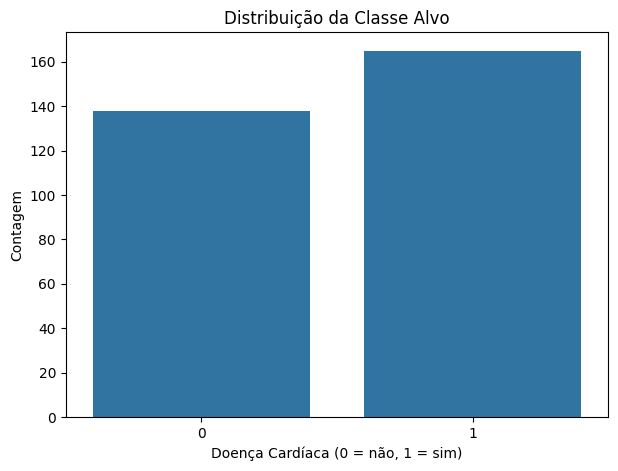

In [6]:
plt.figure(figsize=(7, 5))
sns.countplot(x='target', data=df)
plt.title('Distribuição da Classe Alvo')
plt.xlabel('Doença Cardíaca (0 = não, 1 = sim)')
plt.ylabel('Contagem')
plt.show()

O gráfico de frequência da variável alvo mostra como os casos estão distribuídos entre pacientes com ausência (0) e presença (1) de doença cardíaca. Essa visualização é importante para verificar se existe desbalanceamento entre as classes, o que pode impactar análises e etapas futuras de modelagem.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [7]:
# estatísticas descritivas básicas do dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [8]:
# média dos atributos numéricos do dataset
df.mean(numeric_only=True)

,0
age,54.366337
sex,0.683168
cp,0.966997
trestbps,131.623762
chol,246.264026
fbs,0.148515
restecg,0.528053
thalach,149.646865
exang,0.326733
oldpeak,1.039604


### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [9]:
# desvio padrão dos atributos numéricos do dataset
df.std(numeric_only=True)

,0
age,9.082101
sex,0.466011
cp,1.032052
trestbps,17.538143
chol,51.830751
fbs,0.356198
restecg,0.525860
thalach,22.905161
exang,0.469794
oldpeak,1.161075


## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *age*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

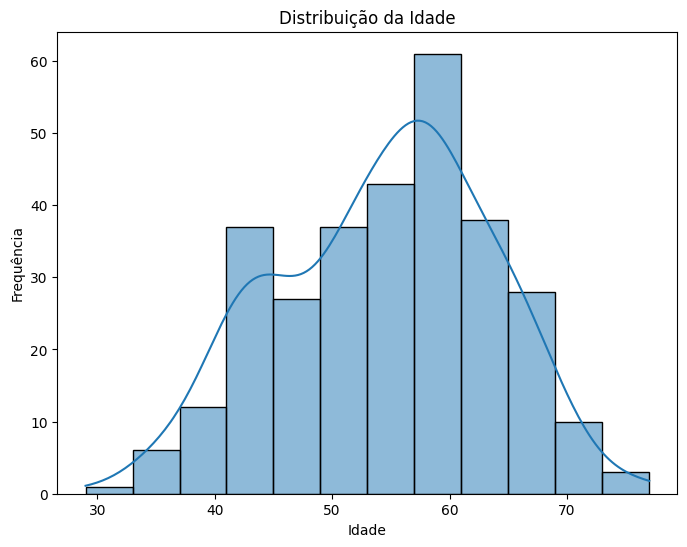

In [18]:
# Histograma da idade
plt.figure(figsize=(8, 6))
sns.histplot(df['age'], kde=True)
plt.title('Distribuição da Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

O histograma da idade mostra como os pacientes estão distribuídos por faixa etária. Observa-se concentração maior em idades adultas e mais avançadas, o que faz sentido para um dataset relacionado a doença cardíaca, já que esse tipo de condição tende a ser mais frequente com o aumento da idade.

### *chol*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

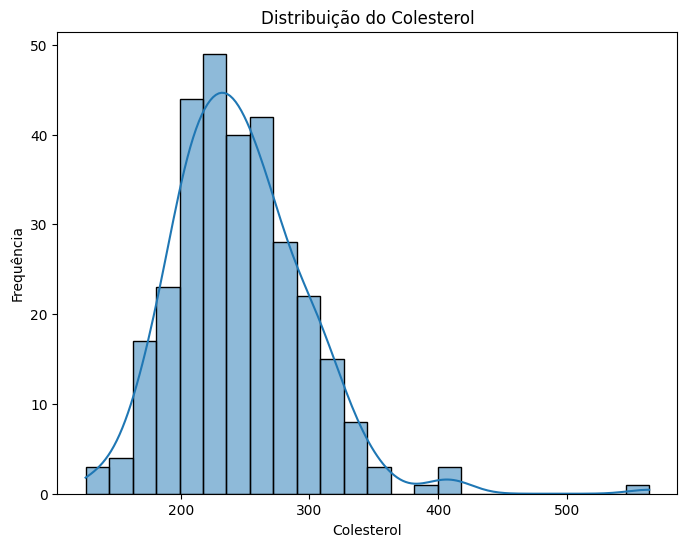

In [11]:
# Histograma do colesterol
plt.figure(figsize=(8, 6))
sns.histplot(df['chol'], kde=True)
plt.title('Distribuição do Colesterol')
plt.xlabel('Colesterol')
plt.ylabel('Frequência')
plt.show()

A distribuição do colesterol mostra concentração em uma faixa intermediária, com presença de alguns valores mais altos. Isso pode indicar assimetria e possíveis valores extremos, o que merece atenção em etapas posteriores de análise e pré-processamento.

## Boxplot

Para entender a dispersão dos dados e a presença de possíveis valores extremos, utilizamos boxplots em variáveis numéricas do dataset. Essa visualização ajuda a comparar mediana, quartis e outliers, sendo útil para apoiar decisões de pré-processamento.

In [12]:
# Estatísticas descritivas
df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### *Boxplot de age


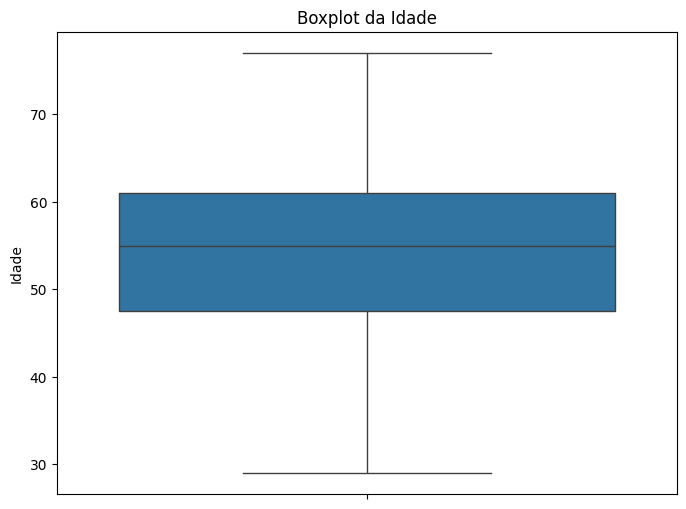

In [13]:
# Boxplot da idade
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['age'])
plt.title('Boxplot da Idade')
plt.ylabel('Idade')
plt.show()

O boxplot da idade permite observar a mediana, a dispersão e possíveis outliers. A presença de valores mais altos não indica necessariamente erro, mas mostra que a base contém pacientes em faixas etárias diversas, o que pode ser relevante para a análise do problema.

### *Boxplot de chol

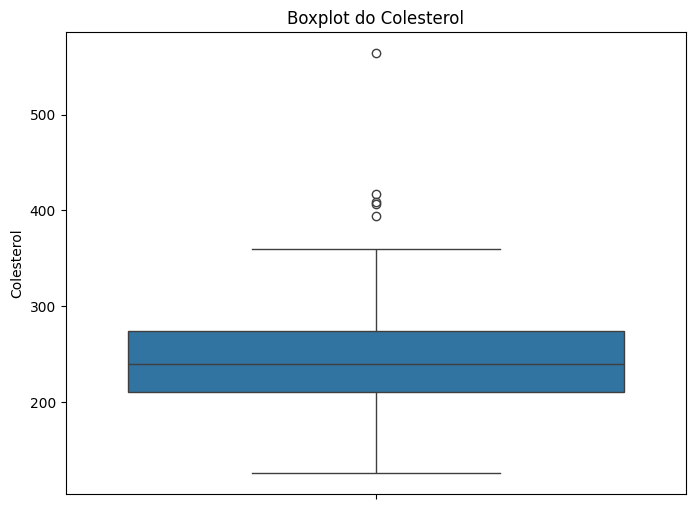

In [14]:
# Boxplot do colesterol
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['chol'])
plt.title('Boxplot do Colesterol')
plt.ylabel('Colesterol')
plt.show()

O boxplot do colesterol destaca a dispersão dos valores e evidencia possíveis outliers. Como se trata de um indicador clínico, valores extremos podem ser importantes para a análise e não devem ser removidos sem critério.

## Matriz de Correlação

A matriz de correlação mede a força e a direção da relação linear entre as variáveis numéricas do dataset. Valores próximos de 1 indicam correlação positiva forte, valores próximos de -1 indicam correlação negativa forte, e valores próximos de 0 indicam ausência de correlação linear.

In [15]:
# Matriz de correlação
print("Matriz de Correlação:")
df.corr(numeric_only=True)

Matriz de Correlação:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


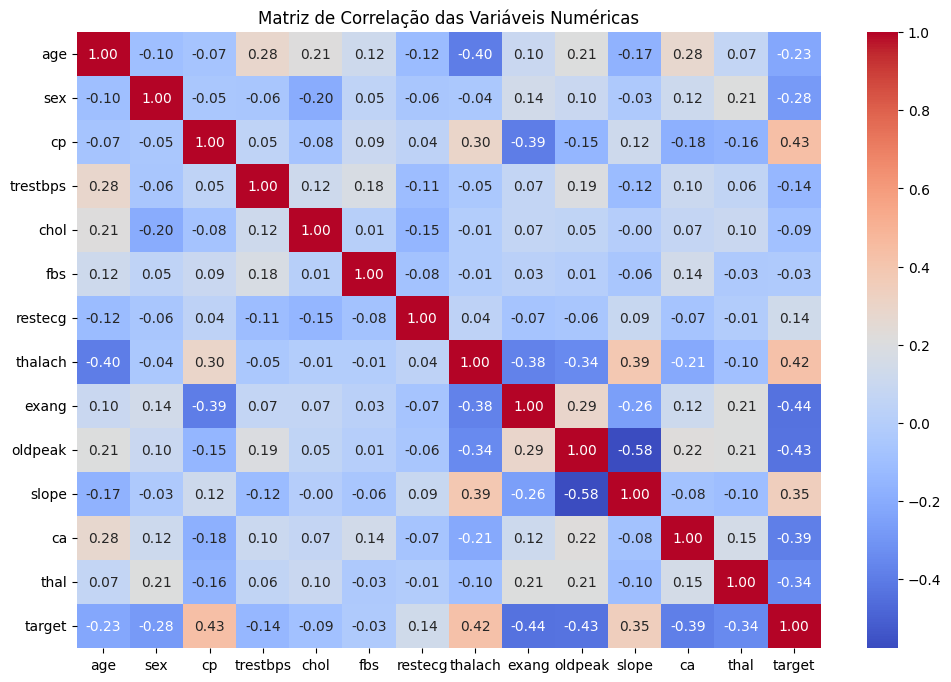

In [16]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

A matriz de correlação permite identificar relações lineares entre as variáveis numéricas do dataset. Observa-se que algumas variáveis apresentam correlação mais forte, o que pode ser útil em futuras etapas de modelagem e seleção de atributos.

## Tratamento de Valores Nulos

Nesta etapa, verificamos se o dataset possui valores ausentes. Essa análise é importante porque valores nulos podem exigir tratamento, como remoção de registros ou imputação, antes de seguir para o pré-processamento.

In [17]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


A verificação mostrou que o dataset não possui valores nulos. Portanto, nesta etapa não foi necessário aplicar técnicas de imputação ou remoção de registros.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [19]:
# Separar features (X) e target (y)
X = df.drop('target', axis=1)
y = df['target']

In [21]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [22]:
print("Dimensão de X_train:", X_train.shape)
print("Dimensão de X_test:", X_test.shape)
print("Dimensão de y_train:", y_train.shape)
print("Dimensão de y_test:", y_test.shape)

Dimensão de X_train: (212, 13)
Dimensão de X_test: (91, 13)
Dimensão de y_train: (212,)
Dimensão de y_test: (91,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.


In [23]:
# Inicializar o MinMaxScaler
scaler_minmax = MinMaxScaler()

In [24]:
# Ajustar no conjunto de treino e transformar treino e teste
X_train_norm = scaler_minmax.fit_transform(X_train)
X_test_norm = scaler_minmax.transform(X_test)

In [25]:
# Exibir as primeiras linhas dos dados normalizados
df_normalized = pd.DataFrame(X_train_norm, columns=X_train.columns)

print("Primeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())

Primeiras 5 linhas dos dados normalizados (treino):
        age  sex        cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.979167  0.0  0.666667  0.469388  0.250883  0.0      1.0  0.245614    0.0   
1  0.291667  0.0  0.000000  0.387755  0.759717  1.0      0.0  0.421053    1.0   
2  0.375000  1.0  0.666667  0.142857  0.413428  0.0      0.5  0.561404    0.0   
3  0.458333  1.0  0.666667  0.061224  0.339223  0.0      0.5  0.482456    1.0   
4  0.583333  1.0  0.000000  0.163265  0.738516  0.0      0.5  0.482456    1.0   

    oldpeak  slope    ca      thal  
0  0.177419    0.5  0.00  0.666667  
1  0.483871    0.5  0.00  1.000000  
2  0.000000    1.0  0.00  0.666667  
3  0.193548    0.5  0.00  0.666667  
4  0.483871    0.5  0.25  1.000000  


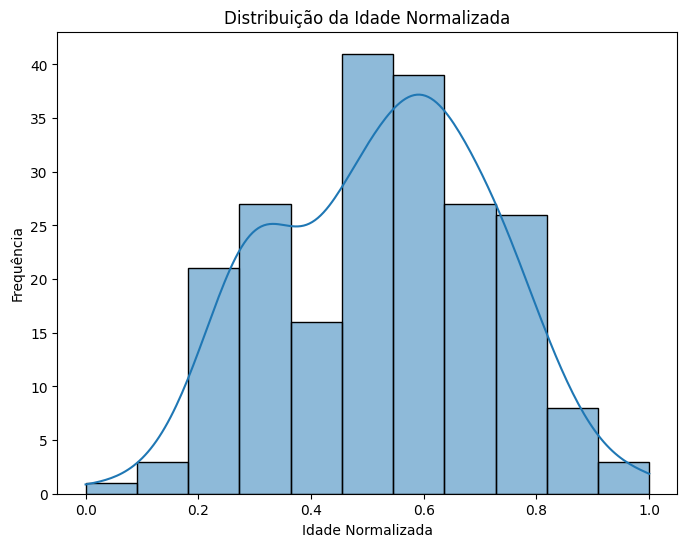

In [26]:
# Visualização da distribuição após a normalização
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['age'], kde=True)
plt.title('Distribuição da Idade Normalizada')
plt.xlabel('Idade Normalizada')
plt.ylabel('Frequência')
plt.show()

Após a normalização, os valores da variável idade passam a ficar em uma escala entre 0 e 1. Essa transformação facilita a comparação entre atributos com magnitudes diferentes e pode beneficiar algoritmos sensíveis à escala dos dados.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [27]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [28]:
# Ajustar no conjunto de treino e transformar treino e teste
X_train_standardized = scaler_std.fit_transform(X_train)
X_test_standardized = scaler_std.transform(X_test)

In [29]:
# Exibir as primeiras linhas dos dados padronizados
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

print("Primeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())

Primeiras 5 linhas dos dados padronizados (treino):
        age      sex        cp  trestbps      chol       fbs   restecg  \
0  2.377169 -1.48732  1.021890  0.459517 -1.019643 -0.390095  2.705952   
1 -1.239767 -1.48732 -0.938659  0.012391  2.030594  2.563480 -1.043472   
2 -0.801351  0.67235  1.021890 -1.328987 -0.045262 -0.390095  0.831240   
3 -0.362934  0.67235  1.021890 -1.776113 -0.490088 -0.390095  0.831240   
4  0.294690  0.67235 -0.938659 -1.217206  1.903501 -0.390095  0.831240   

    thalach     exang   oldpeak     slope        ca      thal  
0 -1.543319 -0.724693  0.018973 -0.683468 -0.705515 -0.568184  
1 -0.631944  1.379895  1.578635 -0.683468 -0.705515  1.081884  
2  0.097156 -0.724693 -0.883989  0.926478 -0.705515 -0.568184  
3 -0.312963  1.379895  0.101061 -0.683468 -0.705515 -0.568184  
4 -0.312963  1.379895  1.578635 -0.683468  0.259448  1.081884  


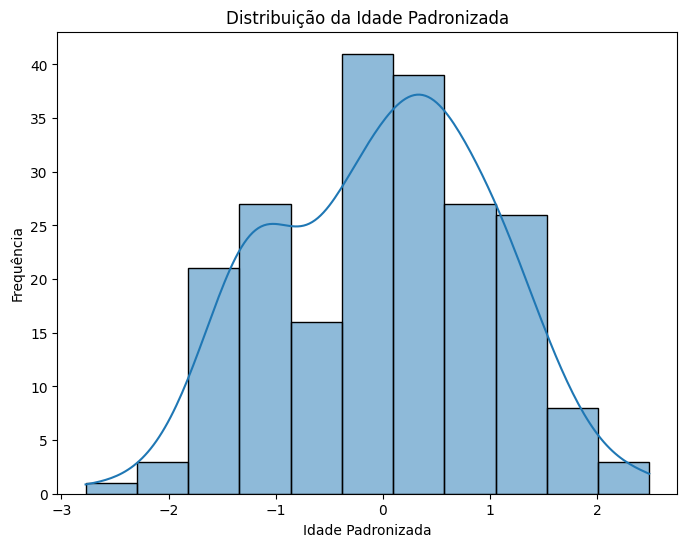

In [30]:
# Visualização da distribuição após a padronização
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['age'], kde=True)
plt.title('Distribuição da Idade Padronizada')
plt.xlabel('Idade Padronizada')
plt.ylabel('Frequência')
plt.show()

Após a padronização, os valores da idade passam a ter média próxima de zero e desvio padrão próximo de um. Essa transformação preserva a forma geral da distribuição, mas ajusta a escala dos dados, o que pode ser útil em futuras etapas de modelagem.

## Outras Transformações e Etapas de Pré-Processamento

Além de normalização e padronização, outras etapas de pré-processamento poderiam ser consideradas, como seleção de atributos, engenharia de variáveis ou análise mais aprofundada de outliers. Neste MVP, as transformações aplicadas já são suficientes para demonstrar a preparação dos dados para modelagem futura.



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1


A análise exploratória sugere que algumas variáveis clínicas possuem relação com a presença de doença cardíaca. A distribuição da classe alvo, os histogramas e a matriz de correlação mostram que existem padrões relevantes no dataset e que alguns atributos podem contribuir mais fortemente para distinguir pacientes com e sem indícios da doença.

## Hipótese 2

Foi confirmada a necessidade de aplicar normalização e padronização, pois o dataset possui variáveis em escalas diferentes, como idade, colesterol, pressão arterial e frequência cardíaca máxima. Essas transformações ajudam a tornar os atributos mais comparáveis e deixam a base mais preparada para futuras etapas de modelagem.

## Hipótese 3

A matriz de correlação mostrou que algumas variáveis apresentam relação linear moderada com a variável alvo e entre si. Isso indica que o dataset possui informações úteis para problemas de classificação supervisionada e reforça a importância de observar redundâncias e relevância dos atributos em modelos futuros.

# Conclusão
Neste MVP foi realizada a análise exploratória e o pré-processamento de um dataset de doença cardíaca. O trabalho permitiu compreender a estrutura da base, identificar os tipos de atributos, verificar a ausência de valores nulos, analisar distribuições, observar possíveis outliers e investigar correlações entre variáveis numéricas.

Além disso, foram aplicadas técnicas de normalização e padronização, preparando os dados para futuras etapas de modelagem preditiva. Os resultados mostraram que o dataset possui características adequadas para um problema de classificação supervisionada, com atributos clínicos relevantes e boa base para análises posteriores.

Dessa forma, o objetivo do MVP foi alcançado ao construir um notebook organizado, documentado e executável, contemplando desde a definição do problema até a preparação dos dados.